# Лабораторная работа №4: Решение краевой задачи для ОДУ второго порядка
## Студент: Сергиенко Александр Сергеевич
### Группа: ФИТ-231

### Вариант 3:
### \(y'' - x y' + 2y = x + 1\)
### \(y(0.9) - 0.5y'(0.9) = 2\), \(y(1.2)=1\)


In [16]:
import numpy as np
import matplotlib.pyplot as plt


def thomas_algorithm(lower, diag, upper, rhs):
    # Решение трехдиагональной СЛАУ методом прогонки.
    n = len(diag) # размер системы
    c_star = np.zeros(n) # коэффициенты для верхней диагонали после прямого хода
    d_star = np.zeros(n) # коэффициенты для правой части после прямого хода 

    c_star[0] = upper[0] / diag[0] # первый элемент верхней диагонали после нормализации
    d_star[0] = rhs[0] / diag[0] # первый элемент правой части после нормализации

    for i in range(1, n):
        denom = diag[i] - lower[i] * c_star[i - 1] # знаменатель для текущей строки после исключения предыдущей
        if i < n - 1:
            c_star[i] = upper[i] / denom 
        d_star[i] = (rhs[i] - lower[i] * d_star[i - 1]) / denom

    y = np.zeros(n)
    y[-1] = d_star[-1] # решение для последнего элемента после обратного хода

    for i in range(n - 2, -1, -1):
        y[i] = d_star[i] - c_star[i] * y[i + 1]

    return y


def solve_bvp_fdm(p, q, r, a, b, bc_left, bc_right, n_nodes):
    # Решение краевой задачи
    # y'' + p(x)y' + q(x)y = r(x), x in [a,b]
    # alpha1*y(a) + beta1*y'(a) = gamma1
    # alpha2*y(b) + beta2*y'(b) = gamma2
    # методом конечных разностей + прогонка.
    alpha1, beta1, gamma1 = bc_left # левая граница
    alpha2, beta2, gamma2 = bc_right # правая граница

    x = np.linspace(a, b, n_nodes) # равномерная сетка
    h = x[1] - x[0] # шаг сетки 

    lower = np.zeros(n_nodes)  # поддиагональ
    diag = np.zeros(n_nodes)   # главная диагональ
    upper = np.zeros(n_nodes)  # наддиагональ
    rhs = np.zeros(n_nodes) # правая часть 

    # Левая граница: alpha1*y0 + beta1*(y1-y0)/h = gamma1
    diag[0] = alpha1 - beta1 / h # коэффициент при y0 в уравнении для левой границы
    upper[0] = beta1 / h # коэффициент при y1 в уравнении для левой границы
    rhs[0] = gamma1 # правая часть для левой границы

    # Правая граница: alpha2*yn + beta2*(yn-yn-1)/h = gamma2
    lower[-1] = -beta2 / h # коэффициент при yn-1 в уравнении для правой границы
    diag[-1] = alpha2 + beta2 / h
    rhs[-1] = gamma2 

    # Внутренние узлы: центральные разности
    for i in range(1, n_nodes - 1):
        xi = x[i]
        pi = p(xi)
        qi = q(xi)
        ri = r(xi)

        lower[i] = 1.0 / h**2 - pi / (2.0 * h)
        diag[i] = -2.0 / h**2 + qi
        upper[i] = 1.0 / h**2 + pi / (2.0 * h)
        rhs[i] = ri

    y = thomas_algorithm(lower, diag, upper, rhs)
    return x, y


def boundary_residual(x, y, bc_left, bc_right):
    # Невязки граничных условий (в той же аппроксимации, что в схеме).
    h = x[1] - x[0]
    alpha1, beta1, gamma1 = bc_left
    alpha2, beta2, gamma2 = bc_right

    left = alpha1 * y[0] + beta1 * (y[1] - y[0]) / h - gamma1
    right = alpha2 * y[-1] + beta2 * (y[-1] - y[-2]) / h - gamma2
    return left, right


## 1. Проверка метода на тестовой задаче (из задания 1)
Решаем задачу Дирихле:

\[
\begin{cases}
 y'' + x y' - 2y = 2, \\
 y(0)=0, \\
 y(1)=1.
\end{cases}
\]

Точное решение: \(y_{\text{точн}} = x^2\).  
Сетка: 11 узлов.


Тестовая задача (11 узлов)
Максимальная абсолютная ошибка: 2.220e-16

 i      x_i         y_числ         y_точн       |ошибка|
 0    0.000     0.00000000     0.00000000      0.000e+00
 1    0.100     0.01000000     0.01000000      4.510e-17
 2    0.200     0.04000000     0.04000000      9.021e-17
 3    0.300     0.09000000     0.09000000      1.388e-16
 4    0.400     0.16000000     0.16000000      1.665e-16
 5    0.500     0.25000000     0.25000000      1.388e-16
 6    0.600     0.36000000     0.36000000      2.220e-16
 7    0.700     0.49000000     0.49000000      1.665e-16
 8    0.800     0.64000000     0.64000000      1.110e-16
 9    0.900     0.81000000     0.81000000      0.000e+00
10    1.000     1.00000000     1.00000000      0.000e+00


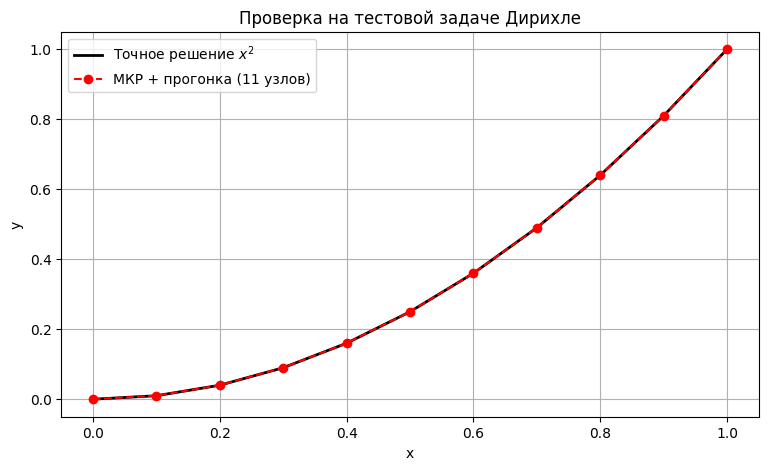

In [17]:
# Тестовая задача
p_test = lambda x: x
q_test = lambda x: -2.0
r_test = lambda x: 2.0

a_test, b_test = 0.0, 1.0
bc_left_test = (1.0, 0.0, 0.0)   # y(0)=0
bc_right_test = (1.0, 0.0, 1.0)  # y(1)=1

x_test, y_test = solve_bvp_fdm(
    p_test, q_test, r_test,
    a_test, b_test,
    bc_left_test, bc_right_test,
    n_nodes=11
)

y_exact = x_test**2
abs_err = np.abs(y_test - y_exact)

print("Тестовая задача (11 узлов)")
print(f"Максимальная абсолютная ошибка: {abs_err.max():.3e}\n")

print(f"{'i':>2} {'x_i':>8} {'y_числ':>14} {'y_точн':>14} {'|ошибка|':>14}")
for i, (xi, yi, ye, er) in enumerate(zip(x_test, y_test, y_exact, abs_err)):
    print(f"{i:2d} {xi:8.3f} {yi:14.8f} {ye:14.8f} {er:14.3e}")

plt.figure(figsize=(9, 5))
plt.plot(x_test, y_exact, 'k-', lw=2, label='Точное решение $x^2$')
plt.plot(x_test, y_test, 'ro--', label='МКР + прогонка (11 узлов)')
plt.grid(True)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Проверка на тестовой задаче Дирихле')
plt.legend()
plt.show()


## 2. Вариант 3: метод конечных разностей и прогонка
Решаем краевую задачу:

\[
\begin{cases}
 y'' - x y' + 2y = x+1, \\
 y(0.9)-0.5y'(0.9)=2, \\
 y(1.2)=1.
\end{cases}
\]

Выполняем расчеты на трех равномерных сетках: 11, 51 и 101 узел.


In [18]:
# Вариант 3
p_var = lambda x: -x
q_var = lambda x: 2.0
r_var = lambda x: x + 1.0

a_var, b_var = 0.9, 1.2
bc_left_var = (1.0, -0.5, 2.0)  # y(0.9)-0.5y'(0.9)=2
bc_right_var = (1.0, 0.0, 1.0)  # y(1.2)=1

grid_sizes = [11, 51, 101]
fdm_solutions = {}

print("Результаты по сеткам:")
print(f"{'Узлов':>8} {'h':>10} {'y(a)':>14} {'y(b)':>14} {'невязка слева':>18} {'невязка справа':>18}")

for n in grid_sizes:
    x_n, y_n = solve_bvp_fdm(
        p_var, q_var, r_var,
        a_var, b_var,
        bc_left_var, bc_right_var,
        n_nodes=n
    )
    fdm_solutions[n] = (x_n, y_n)

    h_n = x_n[1] - x_n[0]
    res_l, res_r = boundary_residual(x_n, y_n, bc_left_var, bc_right_var)

    print(f"{n:8d} {h_n:10.6f} {y_n[0]:14.8f} {y_n[-1]:14.8f} {res_l:18.3e} {res_r:18.3e}")


Результаты по сеткам:
   Узлов          h           y(a)           y(b)      невязка слева     невязка справа
      11   0.030000     1.42348539     1.00000000          3.997e-15          0.000e+00
      51   0.006000     1.42850998     1.00000000          4.885e-15          0.000e+00
     101   0.003000     1.42914702     1.00000000          9.326e-15          0.000e+00


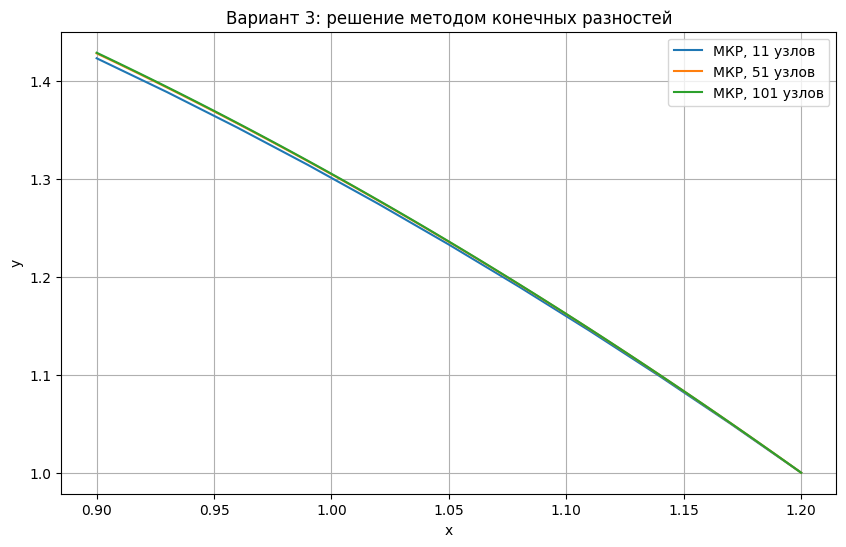

Максимальные отклонения от решения на 101 узле (через линейную интерполяцию):
 11 узлов -> max|y_11(x)-y_101(x)| = 5.712e-03
 51 узлов -> max|y_51(x)-y_101(x)| = 6.409e-04


In [19]:
# Графики решений на сетках 11 / 51 / 101
plt.figure(figsize=(10, 6))
for n, (x_n, y_n) in fdm_solutions.items():
    plt.plot(x_n, y_n, label=f'МКР, {n} узлов')

plt.grid(True)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Вариант 3: решение методом конечных разностей')
plt.legend()
plt.show()

# Сравнение с самым подробным расчетом (101 узел)
x_ref, y_ref = fdm_solutions[101]
print("Максимальные отклонения от решения на 101 узле (через линейную интерполяцию):")
for n in [11, 51]:
    x_n, y_n = fdm_solutions[n]
    y_interp = np.interp(x_ref, x_n, y_n)
    diff = np.max(np.abs(y_interp - y_ref))
    print(f"{n:3d} узлов -> max|y_{n}(x)-y_101(x)| = {diff:.3e}")


## 3. Метод Галеркина (полиномиальный базис, n=2)
Строим аппроксимацию вида
\[
y_G(x)=y_0(x)+c_1\varphi_1(x)+c_2\varphi_2(x),
\]
где \(y_0(x)\) удовлетворяет граничным условиям, а \(\varphi_1,\varphi_2\) — полиномиальные функции,
удовлетворяющие однородным граничным условиям:
\(\varphi(b)=0\), \(\varphi(a)-0.5\varphi'(a)=0\).

Коэффициенты \(c_1,c_2\) определяются из условий Галеркина:
\[
\int_a^b R(y_G)\varphi_i\,dx=0,\quad i=1,2,
\]
где \(R(y)=y''-xy'+2y-(x+1)\).


Проверка φ0 (исходные ГУ):
левое: 2.000000000000, цель: 2.0, невязка: 0.000e+00, выполнено: да
правое: 1.000000000000, цель: 1.0, невязка: 0.000e+00, выполнено: да

Проверка φ1, φ2 (однородные ГУ):
phi1: левое=-1.110e-16, правое=0.000e+00, выполнено=да
phi2: левое=-1.110e-16, правое=0.000e+00, выполнено=да
Ранг базиса: 2/2
Проверка интегралов Галеркина ∫R*phi_i dx:
I1 = -8.778e-16
I2 = 5.551e-16
Коэффициенты Галеркина:
c1 = -0.97403681
c2 = 0.06733960

Проверка однородных ГУ для базисных функций:
phi1: left=-1.110e-16, right=0.000e+00
phi2: left=-1.110e-16, right=0.000e+00

Сравнение Галеркина с МКР (101 узел):
max|y_G - y_MKR| = 6.426e-04
Невязка левого ГУ (Галеркин):  -2.220e-16
Невязка правого ГУ (Галеркин): -1.110e-16


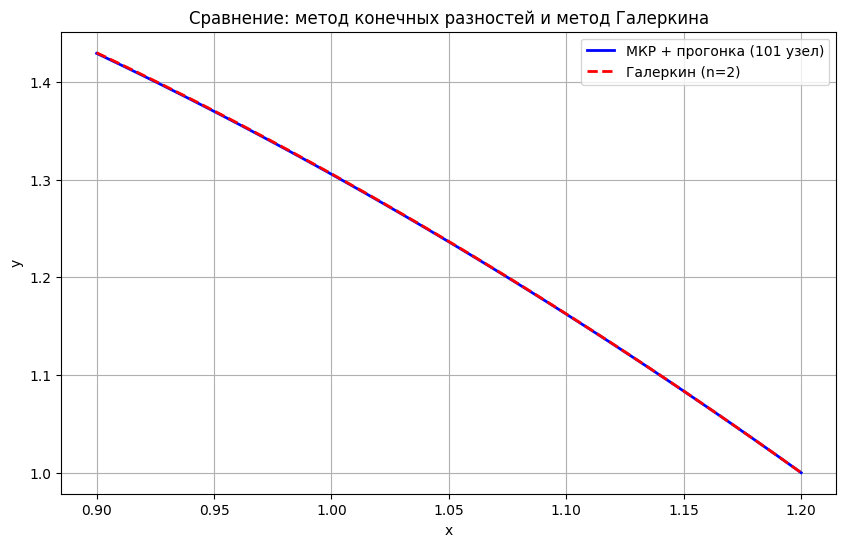

In [20]:
# классический метод Галеркина с полиномиальными базисными функциями

def L_poly(poly):
    # Оператор L(y)=y''-x*y'+2y для полиномов.
    d1 = np.polyder(poly, 1)
    d2 = np.polyder(poly, 2)
    return d2 - np.poly1d([1.0, 0.0]) * d1 + 2.0 * poly


def integrate_poly(poly, a, b):
    # Точное интегрирование полинома на [a,b].
    p_int = np.polyint(poly)
    return float(p_int(b) - p_int(a))

# Базовый линейный полином y0, удовлетворяющий исходным ГУ 
# y0(0.9)-0.5y0'(0.9)=2, y0(1.2)=1
y0 = np.poly1d([-1.25, 2.5])

a, b = a_var, b_var

# Конструируем полиномиальные базисные функции
chi = np.poly1d([1.0, -b])                      # (x-b)
psi1 = np.poly1d([1.0, -(a + b), a * b])        # (x-a)(x-b)
k = 0.5 * (a - b) / ((a - b) - 0.5)
phi1 = psi1 + k * chi # комбинация для удовлетворения левого ГУ
phi2 = np.poly1d(np.polymul(np.poly1d([1.0, -b]), np.poly1d([1.0, -a])**2))
basis = [phi1, phi2] # базисные функции, удовлетворяющие однородным ГУ

eps = 1e-10

# φ0 = y0 должна выполнять исходные граничные условия
phi0 = y0
left0 = phi0(a) - 0.5 * np.polyder(phi0)(a)   # должно быть 2
right0 = phi0(b)                                # должно быть 1

print("Проверка φ0 (исходные ГУ):")
print(f"левое: {left0:.12f}, цель: 2.0, невязка: {left0 - 2.0:.3e}, "
      f"выполнено: {'да' if abs(left0 - 2.0) < eps else 'нет'}")
print(f"правое: {right0:.12f}, цель: 1.0, невязка: {right0 - 1.0:.3e}, "
      f"выполнено: {'да' if abs(right0 - 1.0) < eps else 'нет'}")

# φ1, φ2 должны выполнять однородные условия
print("\nПроверка φ1, φ2 (однородные ГУ):")
for i, phi in enumerate(basis, 1):
    left = phi(a) - 0.5 * np.polyder(phi)(a)   # должно быть 0
    right = phi(b)                              # должно быть 0
    ok = abs(left) < eps and abs(right) < eps
    print(f"phi{i}: левое={left:.3e}, правое={right:.3e}, выполнено={'да' if ok else 'нет'}")


# Линейная система для коэффициентов Галеркина
R0 = L_poly(y0) - np.poly1d([1.0, 1.0]) 
A = np.zeros((2, 2))
b_vec = np.zeros(2) 

for i, phi_i in enumerate(basis): # ортогональность невязки к тестовым функциям.
    b_vec[i] = integrate_poly(np.polymul(R0, phi_i), a, b)
    for j, phi_j in enumerate(basis):
        A[i, j] = integrate_poly(np.polymul(L_poly(phi_j), phi_i), a, b) # ∫ab R(yG​)φi ​dx=0 — ортогональность невязки к тестовым функциям.

c1, c2 = np.linalg.solve(A, -b_vec)
y_gal = y0 + c1 * phi1 + c2 * phi2

# Проверка 1: линейная независимость phi
X_rank = np.linspace(a, b, 50)
M = np.column_stack([phi(X_rank) for phi in basis])
rank = np.linalg.matrix_rank(M)
print(f"Ранг базиса: {rank}/{len(basis)}")

# Проверка 2: условия Галеркина (интегралы невязки должны быть ~0)
R = L_poly(y_gal) - np.poly1d([1.0, 1.0])
print("Проверка интегралов Галеркина ∫R*phi_i dx:")
for idx, phi in enumerate(basis, start=1):
    I = integrate_poly(np.polymul(R, phi), a, b)
    print(f"I{idx} = {I:.3e}")

print("Коэффициенты Галеркина:")
print(f"c1 = {c1:.8f}")
print(f"c2 = {c2:.8f}\n")

print("Проверка однородных ГУ для базисных функций:")
for idx, phi in enumerate(basis, start=1):
    left_h = phi(a) - 0.5 * np.polyder(phi)(a)
    right_h = phi(b)
    print(f"phi{idx}: left={left_h:.3e}, right={right_h:.3e}")

# Сравнение с МКР на 101 узле
x_101, y_101 = fdm_solutions[101]
y_gal_101 = y_gal(x_101)
max_diff_gal_fdm = np.max(np.abs(y_gal_101 - y_101))

# Невязки ГУ для y_G
left_bc_gal = y_gal(a) - 0.5 * np.polyder(y_gal)(a) - 2.0
right_bc_gal = y_gal(b) - 1.0

print("\nСравнение Галеркина с МКР (101 узел):")
print(f"max|y_G - y_MKR| = {max_diff_gal_fdm:.3e}")
print(f"Невязка левого ГУ (Галеркин):  {left_bc_gal:.3e}")
print(f"Невязка правого ГУ (Галеркин): {right_bc_gal:.3e}")

plt.figure(figsize=(10, 6))
plt.plot(x_101, y_101, 'b-', lw=2, label='МКР + прогонка (101 узел)')
plt.plot(x_101, y_gal_101, 'r--', lw=2, label='Галеркин (n=2)')
plt.grid(True)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Сравнение: метод конечных разностей и метод Галеркина')
plt.legend()
plt.show()


## 4. Для каждого из реализованных методов нужно уметь отвечать на вопросы:

1. Суть реализованных методов:
Метод конечных разностей заменяет производные на значения в узлах сетки и сводит задачу к системе уравнений, которую решаем прогонкой.
Метод Галеркина ищет решение как формулу с неизвестными коэффициентами и подбирает их так, чтобы в среднем ошибка была минимальной.

2. Как проверить правильность и точность:
Берем тестовую задачу с известным точным решением и сравниваем результаты.
Для метода конечных разностей уменьшаем шаг сетки: если метод работает правильно, ошибка должна уменьшаться.
Также проверяем, что выполняются граничные условия, и сравниваем результаты двух методов между собой.

3. Преимущества и ограничения:
Конечные разности + прогонка: просто, быстро и удобно для линейных задач, но точность зависит от шага сетки.
Галеркин: дает гладкое приближение и гибко настраивается через базис, но сложнее в вычислениях и чувствителен к выбору базисных функций.

4. В каком виде получено решение:
В методе конечных разностей решение получено как таблица значений в узлах сетки (и график).
В методе Галеркина решение получено как явная формула (полином с найденными коэффициентами) и график.